In [113]:
import numpy as np
import matplotlib.pyplot as plt
import pulser
import pulser_simulation
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform, euclidean

In [114]:
Q = np.array(
    [
        [0, 1, 1, 1],
        [1, 2, 0, 0],
        [1, 0, 2, 1],
        [1, 0, 1, 0],
    ]
)

In [115]:
device = pulser.MockDevice
device.print_specs()

-------------------------
MockDevice Specifications
-------------------------
A virtual device for unconstrained prototyping.

Register parameters:
 - Dimensions: 3D
 - Minimum distance between neighbouring atoms: 0.0 μm

Layout parameters:
 - Requires layout: No
 - Minimal number of traps: 1
 - Minimum layout filling fraction: 0.0
 - Maximum layout filling fraction: 0.5

Device parameters:
 - Rydberg level: 70
 - Ising interaction coefficient: 5420158.53
 - XY interaction coefficient: 3700.0
 - Channels can be reused: Yes
 - Supported bases: ground-rydberg, digital, XY
 - Supported states: u, d, r, g, h
 - SLM Mask: Yes

Channels:
 - 'rydberg_global': Rydberg(addressing='Global',
        max_abs_detuning=None,
        max_amp=None,
        min_retarget_interval=None,
        fixed_retarget_t=None,
        max_targets=None,
        clock_period=1,
        min_duration=1,
        max_duration=None,
        min_avg_amp=0,
        mod_bandwidth=None,
        custom_phase_jump_time=None,
 

In [116]:
# Facteur de normalisation /4 : Compense le fait que la matrice Q théorique utilise 
# des couplages unitaires (1). Diviser par 4 tasse globalement l'échelle d'énergie,
# ce qui force l'optimiseur à rapprocher les atomes (~10.5 µm au lieu de ~13.2 µm).
# Grâce à la loi en 1/R^6, ce léger rapprochement multiplie par 4 la force réelle
# des interactions physiques, améliorant la robustesse au bruit de la machine.

def evaluate_mapping(
        new_coords: np.ndarray, Q: np.ndarray, device: pulser.devices.Device
):
    """ Cost function to minimize."""
    new_coords = np.reshape(new_coords, (len(Q),2))
    new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6) / 4 # <- Ce facteur
    return np.linalg.norm(new_Q - Q)

In [117]:
costs = []
np.random.seed(0)
x0 = np.random.random(len(Q) * 2)
res = minimize(
    evaluate_mapping,
    x0,
    args=(~np.eye(Q.shape[0], dtype=bool) * Q, device),
    method="Nelder-Mead",
    tol=1e-6,
    options={"maxiter": 200000, "maxfev": None}
)
coords = np.reshape(res.x, (len(Q),2))

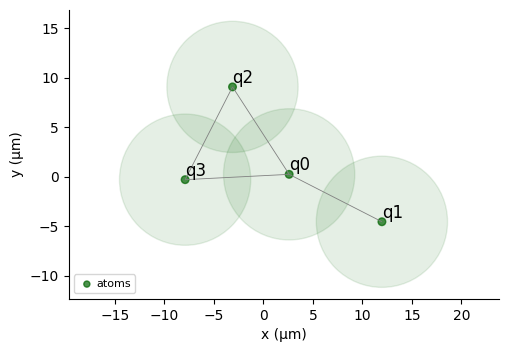

In [118]:
qubits = {f"q{i}": coord for (i, coord) in enumerate(coords)}
reg = pulser.Register(qubits)
reg.draw(
    blockade_radius=device.rydberg_blockade_radius(1.0),
    draw_graph=True,
    draw_half_radius=True
)

In [119]:
sequence = pulser.Sequence(reg, device)

In [120]:
sequence.declare_channel("rydberg_global", "rydberg_global")

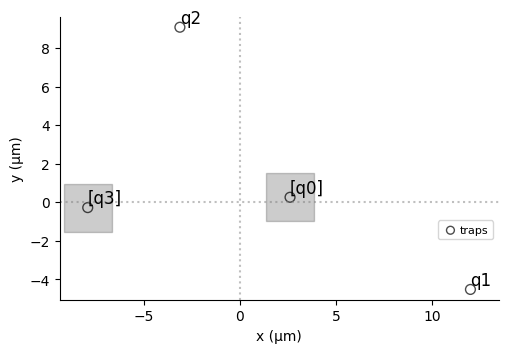

In [121]:
node_weights = np.diag(Q)
norm_node_weights = node_weights / np.max(node_weights)
det_map_weights = 1 - norm_node_weights
det_map = reg.define_detuning_map(
    {f"q{i}": det_map_weights[i] for i in range(len(det_map_weights))}
)
det_map.draw(labels=reg.qubit_ids)

In [122]:
# Masque DMM par pénalisation inverse : les sommets à fort poids (q1, q2 -> poids 2) reçoivent un poids DMM de 0 
# Les sommets faibles (q0, q3 -> poids 0) reçoivent un poids DMM de 1 (carrés gris) 

In [123]:
sequence.config_detuning_map(det_map, "dmm_0")

In [124]:
# Calcule Ω_max basé sur la paire d'atomes non connectés la plus proche (pire cas).
# Le facteur 10 augmente la puissance du laser (Rabi) pour surmonter les barrières
# d'énergie locales et garantir le flip des atomes non connectés si nécessaire.
#
# Dynamique temporelle (Verrouillage DMM) :
# - Nœuds de poids max (eps_k = 0) : detuning total finit à +delta_f (> 0) -> ils flippent à 1 tôt.
# - Nœuds de poids intermédiaire (0 < eps_k < 1) : detuning total finit positif -> ils flippent plus tard.
# - Nœuds de poids nul (eps_k = 1) : detuning total stagne à 0 en fin de cycle -> ils ne flippent jamais.
#   Bloquer les poids 0 à l'état 0 ne détruit pas l'optimalité du MWIS : activer un nœud de poids 0
#   n'apporte aucun point et risquerait de bloquer par interaction de Rydberg des voisins à fort poids.

# Compute the maximum interaction between two non-connected atoms
distance_non_connected = []
for i in range(1, Q.shape[0]):
    for j in range(i - 1):
        if Q[i, j] == 0:
            distance_non_connected.append(
                euclidean(reg.qubits[f"q{i}"], reg.qubits[f"q{j}"])
            )
Omega = device.interaction_coeff /  np.min(distance_non_connected) ** 6 * 10
delta_0 = - Omega #Just need a <0 real
delta_f = - delta_0 #Just needs to be >0 real
T = 40000 # Time in ns : it should be long enough to ensure information propagation (<=> adiabatic)

print(f"Omega : {Omega}")
print(f"delta_0 : {delta_0}")
print(f"delta_f : {delta_f}")

Omega : 0.7692748814896316
delta_0 : -0.7692748814896316
delta_f : 0.7692748814896316


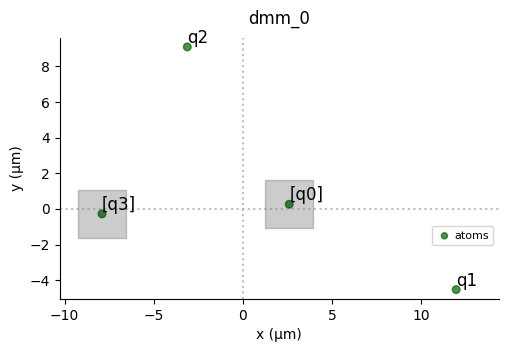

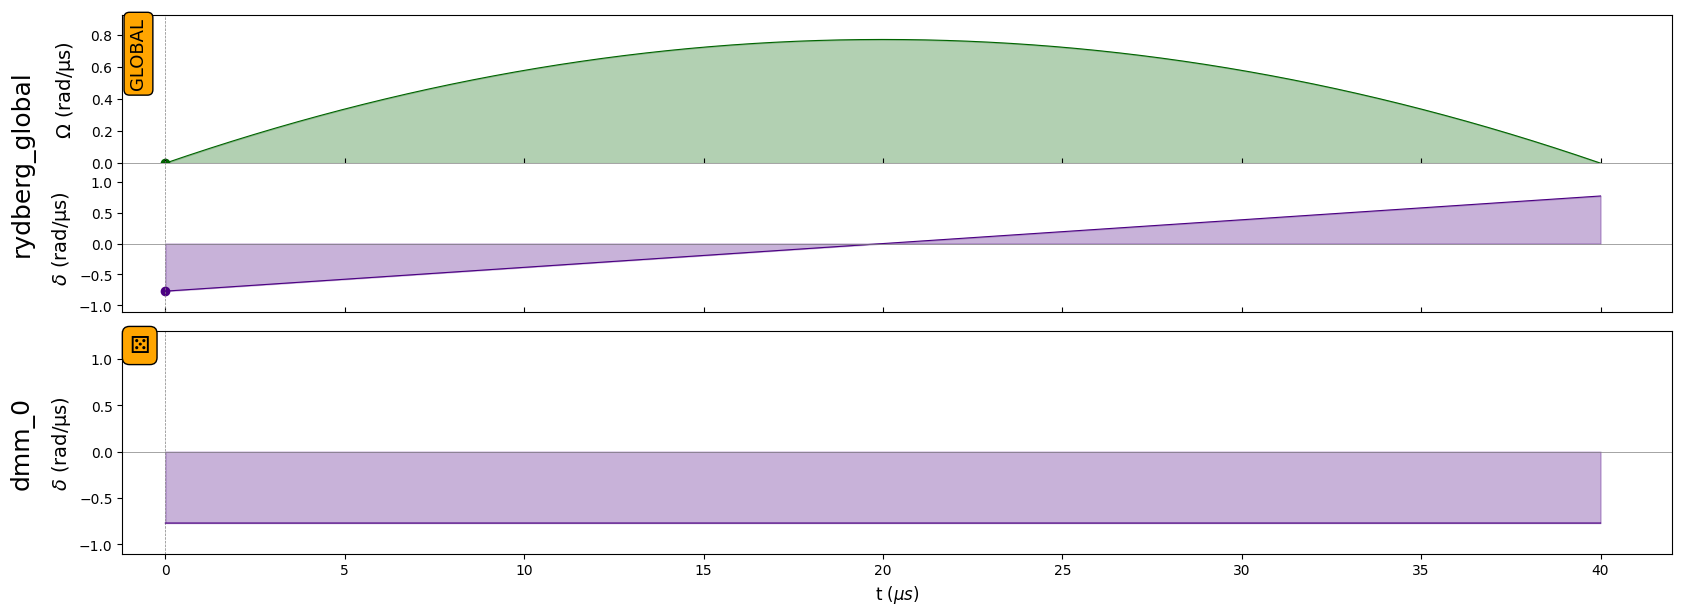

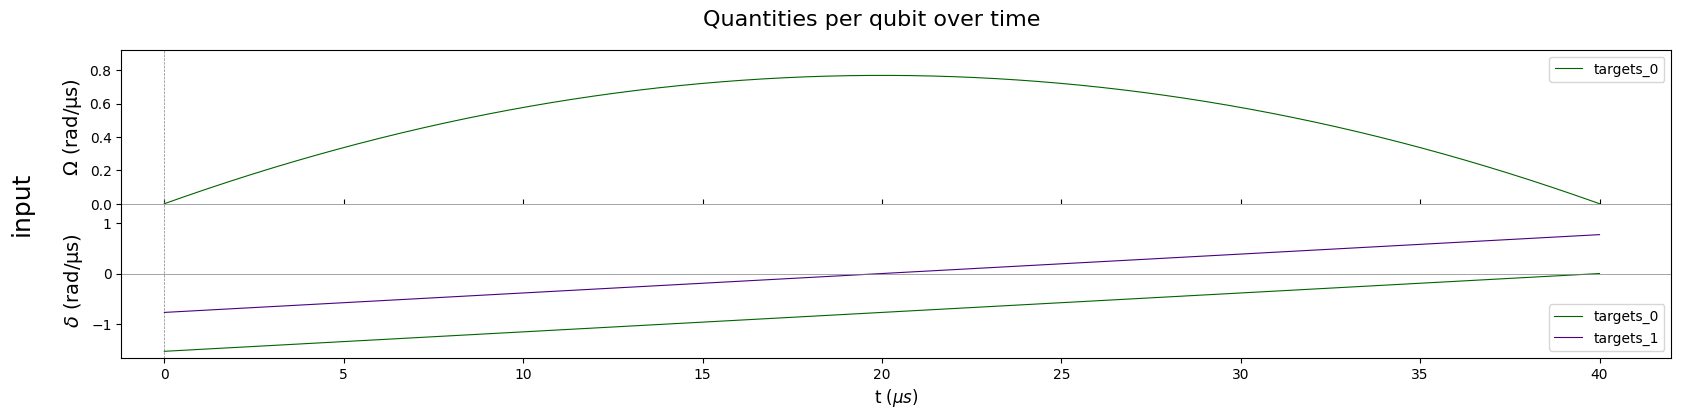

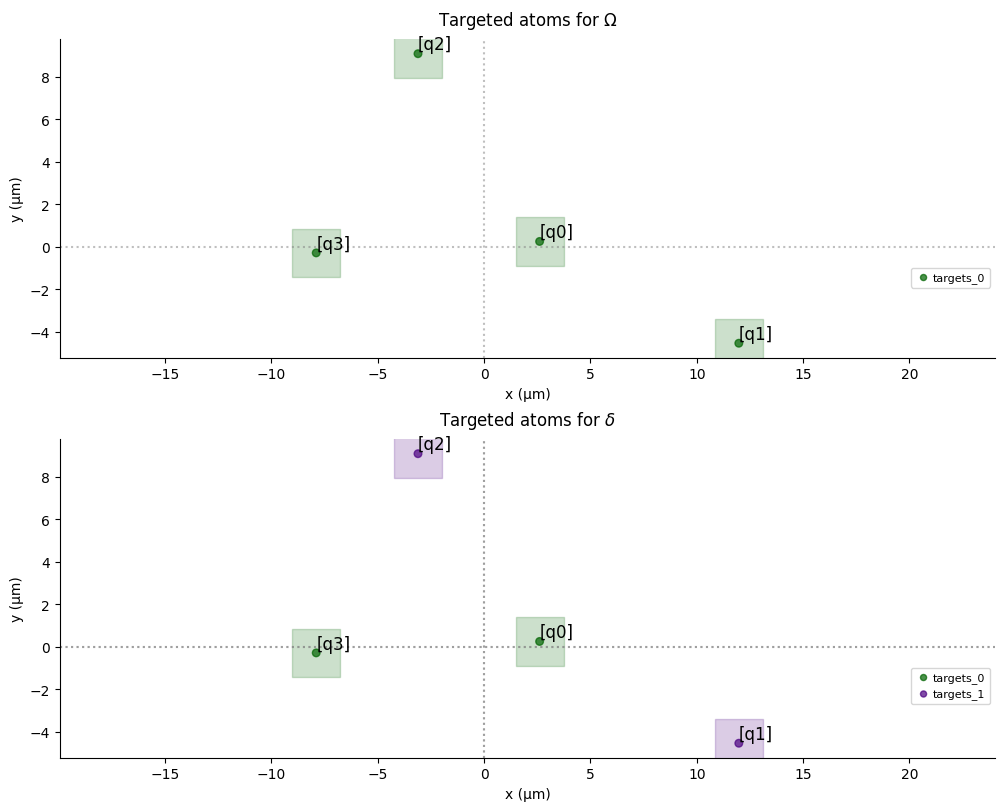

In [125]:
#Adiabatic pulse added to the Rydberg Global
adiabatic_pulse = pulser.Pulse(
    pulser.InterpolatedWaveform(T, [1e-9, Omega, 1e-9]),
    pulser.InterpolatedWaveform(T, [delta_0, 0, delta_f]),
    0
)
sequence.add(adiabatic_pulse, "rydberg_global")

# Constant pulse added to the DMM
sequence.add_dmm_detuning(pulser.ConstantWaveform(T, -delta_f), "dmm_0")
sequence.draw(
    draw_detuning_maps=True,
    draw_qubit_det=True,
    draw_qubit_amp=True,
)

In [127]:
simul = pulser_simulation.QutipBackendV2(sequence)
results = simul.run()
count_dict = results.final_bitstrings

In [129]:
def plot_distribution(C):
    C = dict(sorted(C.items(), key=lambda item: item[1], reverse=True))
    indexes = ["0110"] #best solution
    color_dict = {key: "r" if key in indexes else "g" for key in C}
    plt.figure(figsize=(12, 6))
    plt.xlabel("bitstrings")
    plt.ylabel("counts")
    plt.bar(C.keys(), C.values(), width=0.5, color=color_dict.values())
    plt.xticks(rotation="vertical")
    plt.show()

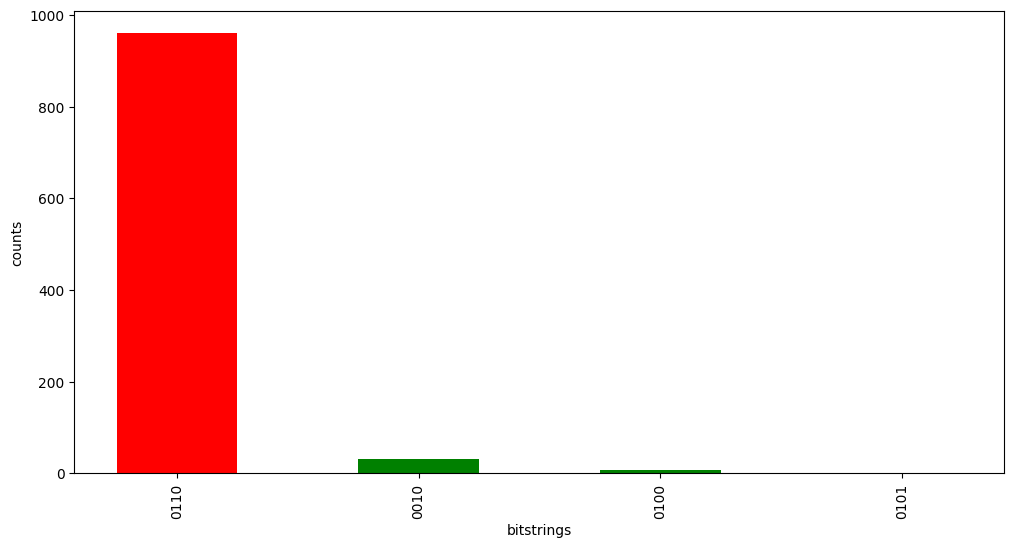

In [130]:
plot_distribution(count_dict)